## MSE 546 Project Proposal Code

### Exploratory Data Analysis

In [169]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import random


from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [170]:
# Load data in dataframe
train_student_data = pd.read_csv("train.csv")
test_student_data = pd.read_csv("test.csv")

train_student_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.910000,98.800000,no,4.900000,average,online videos,low,easy,78.300000
1,1,18,other,diploma,4.950000,94.800000,yes,4.700000,poor,self-study,medium,moderate,46.700000
2,2,20,female,b.sc,4.680000,92.600000,yes,5.800000,poor,coaching,high,moderate,99.000000
3,3,19,male,b.sc,2.000000,49.500000,yes,8.300000,average,group study,high,moderate,63.900000
4,4,23,male,bca,7.650000,86.900000,yes,9.600000,good,self-study,high,easy,100.000000


In [171]:
train_student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [172]:
# Drop ID column (redundant)
id_data = test_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Explore all unique values for categorical features

print("Unique Gender:", train_student_data["gender"].unique())
print("Unique Course:", train_student_data["course"].unique())
print("Unique Internet Access:", train_student_data["internet_access"].unique())
print("Sleep Quality:", train_student_data["sleep_quality"].unique())
print("Study Method:", train_student_data["study_method"].unique())
print("Facility Rating:", train_student_data["facility_rating"].unique())
print("Exam Difficulty:", train_student_data["exam_difficulty"].unique())


Unique Gender: ['female' 'other' 'male']
Unique Course: ['b.sc' 'diploma' 'bca' 'b.com' 'ba' 'bba' 'b.tech']
Unique Internet Access: ['no' 'yes']
Sleep Quality: ['average' 'poor' 'good']
Study Method: ['online videos' 'self-study' 'coaching' 'group study' 'mixed']
Facility Rating: ['low' 'medium' 'high']
Exam Difficulty: ['easy' 'moderate' 'hard']


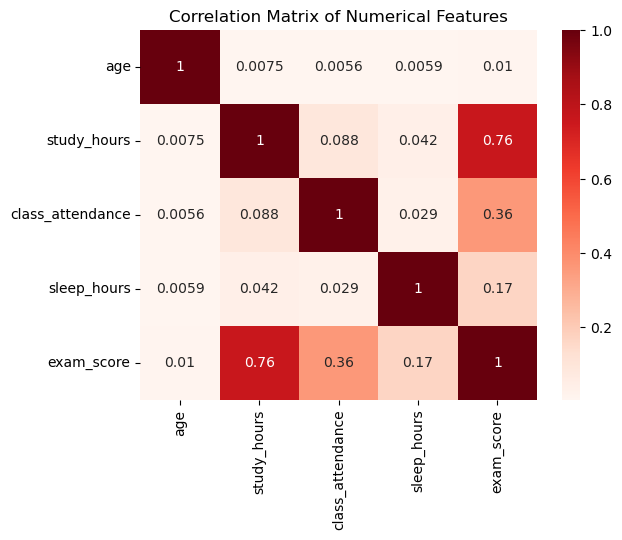

In [173]:
# Analyze correlation between numerical features
numerical_features = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
corr_matrix = train_student_data[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Reds")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [174]:
# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})    

# One Hot Encode remaining categorical features

categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# View all hot encoded categorical features (for viewing)
print(one_hot_names)

['gender_male' 'gender_other' 'course_b.sc' 'course_b.tech' 'course_ba'
 'course_bba' 'course_bca' 'course_diploma' 'sleep_quality_good'
 'sleep_quality_poor' 'study_method_group study' 'study_method_mixed'
 'study_method_online videos' 'study_method_self-study'
 'facility_rating_low' 'facility_rating_medium' 'exam_difficulty_hard'
 'exam_difficulty_moderate']


In [175]:
# Print new dataframe
train_student_data.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,21,7.910000,98.800000,0,4.900000,78.300000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1,18,4.950000,94.800000,1,4.700000,46.700000,0.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2,20,4.680000,92.600000,1,5.800000,99.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
3,19,2.000000,49.500000,1,8.300000,63.900000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
4,23,7.650000,86.900000,1,9.600000,100.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000


### 1. Linear Regression: Baseline Case

In [176]:
# Remove target feature from feature list
target = "exam_score"

features = list(train_student_data.columns)
features.remove(target)

X_train = train_student_data[features]
y_train = train_student_data[target]

X_test = test_student_data[features]

# Train on linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Print Linear Regression Coefficients
print("Intercept:", lin_reg.intercept_)
pd.DataFrame(lin_reg.coef_, features, columns = ["Coefficient"])

Intercept: 17.728246502681003


,Coefficient
age,-0.013699
study_hours,5.676465
class_attendance,0.312254
internet_access,0.023373
sleep_hours,1.321698
gender_male,-0.105472
gender_other,0.190581
course_b.sc,-0.177876
course_b.tech,0.167018
course_ba,-0.033243


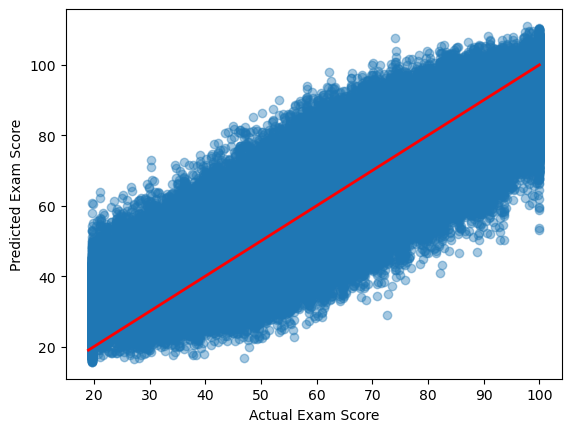

In [177]:
# Evaluate model performance (training data)
y_train_pred = lin_reg.predict(X_train)

# Graph actual vs predicted in scatter plot for training data
plt.scatter(y_train, y_train_pred, alpha=0.4)
plt.plot([19, 100], [19, 100], 'r', lw=2) 

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()

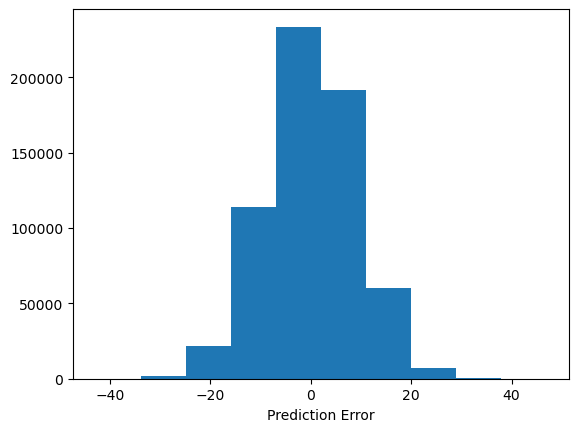

In [178]:
plt.hist(y_train - y_train_pred)
plt.xlabel("Prediction Error")
plt.show()

In [179]:
# Regression Model Evaluation Metrics (training data)

res_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_train, y_train_pred)],
  "MSE": [metrics.mean_squared_error(y_train, y_train_pred)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))],
  "R2": [metrics.r2_score(y_train, y_train_pred)] 
})

pd.set_option("float_format", "{:f}".format)
res_metrics

,MAE,MSE,RMSE,R2
0,7.100962,79.110443,8.894405,0.778927


### 2. Genetic Algorithm Solution

In [180]:
# Building a population of original linear regression solutions (50 total)

# All Features (Baseline) - All 1s
feature_count = len(lin_reg.coef_)
baseline = [1] * feature_count

# Build population of similar solutions (Exploitation)
pop = []
pop.append(baseline.copy())

for i in range(10): # Population size of 10
    ind = baseline.copy()

    # Randomly Exclude 10% of features
    for j in range(feature_count):
        if np.random.rand() < 0.1:
            ind[j] = 0 # Feature excluded
    pop.append(ind)


# Build population of random solutions (Exploration)
for i in range(50): # Population size of 40
    ind = []
    for j in range(feature_count):
        ind.append(1 if np.random.rand() > 0.5 else 0) # Randomly include/exclude features with 50% chance
    pop.append(ind)

# print (pop)

In [181]:
# Calculating fitness of individual
def calculate_fitness(individual):

    # Create modified feature set based on individual's binary feature selection
    # 1 include feature, 0 exclude feature
    ind_X_train = X_train.copy()
    for i, include in enumerate(individual):
        if include == 0:
            ind_X_train.iloc[:, i] = 0 # Exclude feature by setting to 0
    
    # Train linear regression on modified features
    model = LinearRegression()
    model.fit(ind_X_train, y_train)
    
    # Predict and calculate RMSE Score
    y_pred = model.predict(ind_X_train)
    fitness = np.sqrt(metrics.mean_squared_error(y_train, y_pred))
    
    return fitness


In [182]:
# Ranked based selection (Higher fitness = higher chance of selection)
def rank_select (population, fitnesses, selected_count):
    
    # Rank individuals based on fitness
    ranked_ind = np.argsort(fitnesses)

    # Select top individuals
    selected = ranked_ind[:selected_count]
    return [population[i] for i in selected]

In [183]:
# Uniform Crossover (Equal chance to inherit from either parent)
def crossover (p1, p2):
    child = []

    # Child inherits has 50% chance to inherit each feature from either parent
    for i in range(len(p1)):
        child.append(p1[i] if np.random.rand() > 0.5 else p2[i])
    return child

In [184]:
# Encourage Mutation to explore
def mutate(individual, mutation_rate=0.1):

    # Feature has a small chance to be switched
    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i] # From 0 to 1, or 1 to 0
    return individual

In [185]:
# Simulate 100 Generations
for gen in range(100):
    
    # Calculate fitness of population
    fitnesses = [calculate_fitness(ind) for ind in pop]

    # Select top 10% of population
    selected = rank_select(pop, fitnesses, selected_count=int(len(pop)*0.1))

    # Using the top % of population, create offspring
    new_pop = []
    while len(new_pop) < len(pop):
        p1, p2 = random.sample(selected, 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    pop = new_pop
    

KeyboardInterrupt: 

In [ ]:
# Output the GA results training error
best_individual = pop[0]
best_fitness = calculate_fitness(best_individual)

# Train on linear regression model with best GA individual features
ga_model = LinearRegression()
ga_model.fit(X_train, y_train)

# Training Error will be lower than the original linear regression model, but should not be better on test data due to overfitting
print (best_individual)
print (best_fitness)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
9.095489368266255


### Build Submission csvs to Evaluate Test Error

In [ ]:
# Generate test predicitions
def test_prediction(coefficients, intercept):

    coefficients = np.array(coefficients) # Convert to numpy array for dot product
    exam_score = intercept + test_student_data.values.dot(coefficients)

    df_test_pred = pd.DataFrame({
        "id": id_data,
        "exam_score": exam_score
    })
    return df_test_pred

In [ ]:
# Generate submission CSVs
df_lr = test_prediction(lin_reg.coef_, lin_reg.intercept_)
df_lr.to_csv("linear_regression_submission.csv", index=False)

df_ga = test_prediction(ga_model.coef_, ga_model.intercept_)
df_ga.to_csv("genetic_algorithm_submission.csv", index=False)